<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/iLogos/logo_novafct.png" width="200">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica dos Sólidos II

## Flexão de vigas constituídas por vários materiais.

### Problema 5

A figura representa uma viga com 4 m de comprimento composta por um barrote de madeira colado a uma barra de aço que suporta uma carga concentrada $P$ a meio vão. A sua secção transversal está também representada na figura. Considere as propriedades do aço ($E=$ 210 GPa, $\sigma_\mathrm{adm}$ = 355 MPa) e da madeira ($E$ = 10 GPa, $\sigma_\mathrm{adm(compressão)}$ = 36 MPa) e determine:

a) O valor da maior carga $P$ que pode ser aplicada na viga composta.

b) Para a carga $P$ calculada na alínea a), desenhe a distribuição de tensões normais ao longo do eixo vertical, indicando os seus valores máximos e ainda os valores obtidos na zona de transição entre os dois materiais.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au02/P5/MSII_Au02_P5.png"
style="max-height: 100%; max-width: 100%;"/>

#### Nomenclatura

- $E_\mathrm{s}$ : modulus of elasticity of steel, GPa
- $E_\mathrm{w}$ : modulus of elasticity of wood, GPa

### Resolução

**a) O valor da maior carga $P$ que pode ser aplicada na viga composta.**

 Wood section : 150.0 mm x 150.0 mm = 22500.0 mm²
Steel section :  150.0 mm x 20.0  mm = 3000.0   mm²


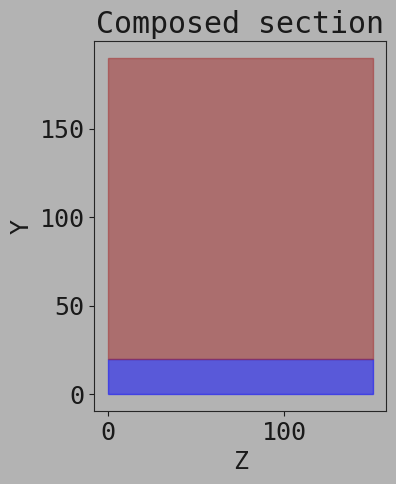

In [1]:
import numpy as np
import sympy as sy
from sympy.solvers import solve
import matplotlib.pyplot as plt
import os

cor = '2'
if cor == '1':
    plt.rcParams['axes.facecolor'] = (.15, .15, .15)
    plt.rcParams['figure.facecolor'] = (.15, .15, .15)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.8, .8, .8),
              "xtick.color" : (.8, .8, .8),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.7, .7, .7),
              "axes.labelcolor" : (.8, .8, .8),
              "axes.edgecolor" : (.15, .15, .15)}
else:
    plt.rcParams['axes.facecolor'] = (.7, .7, .7)
    plt.rcParams['figure.facecolor'] = (.7, .7, .7)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.1, .1, .1),
              "xtick.color" : (.1, .1, .1),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.1, .1, .1),
              "axes.labelcolor" : (.1, .1, .1),
              "axes.edgecolor" : (.15, .15, .15)}
plt.rcParams.update(params)

# data structure, units: N, mm, MPa
# Create an empty class
class varin: pass

Steel = varin()
Wood = varin()
S = varin()
L = 2e3 # unit: mm

Steel.E = 210.e3 # MPa
Steel.Sadm = 355. # MPa

Wood.E = 10.e3 # MPa
Wood.Sadm = 36. # MPa

S.l = 150 # mm
S.hs = 20 # mm - streel height
S.hw = 150 # mm - woood height

S.Aw = S.l*S.hw
print(f' Wood section : {S.l:.1f} mm x {S.hw:.1f} mm = {S.Aw:.1f} mm²')
S.As = S.l*S.hs
print(f'Steel section :  {S.l:.1f} mm x {S.hs:.1f}  mm = {S.As:.1f}   mm²')

from matplotlib.patches import Rectangle

fig, ax = plt.subplots()
ax.plot([0],[0],color="black")
ax.add_patch(Rectangle((0, 0), S.l, S.hs,color="blue",alpha=0.5))
ax.add_patch(Rectangle((0, S.hs), S.l, S.hs+S.hw,color="brown",alpha=0.5))
plt.xlabel("Z")
plt.ylabel("Y")
plt.title("Composed section")
ax.set_aspect('equal')
plt.show()

### Secção transversal homogénea de aço

A transformação da região de madeira em aço pode ser obtida usando o seguinte rácio material:

\begin{equation*}
n = \frac{E_\mathrm{w}}{E_\mathrm{s}}
\end{equation*}

n = Es/Ew = 0.048 
ls2w = n*l = 7.143 


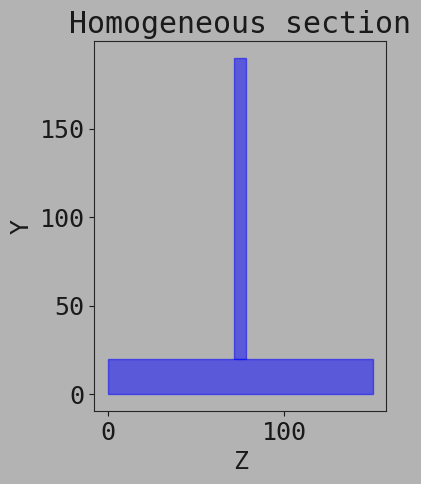

In [2]:
S.n = Wood.E/Steel.E
print(f'n = Es/Ew = {S.n:.3f} ')

print(f'ls2w = n*l = {S.n*S.l:.3f} ')

fig, ax = plt.subplots()
ax.plot([0],[0],color="black")
ax.add_patch(Rectangle((0, 0), S.l, S.hs,color="blue",alpha=0.5))
ax.add_patch(Rectangle((S.l/2*(1-S.n), S.hs), S.l*S.n, S.hs+S.hw,color="blue",alpha=0.5))
plt.xlabel("Z")
plt.ylabel("Y")
plt.title("Homogeneous section")
ax.set_aspect('equal')
plt.show()

In [3]:
S.ys = S.hs/2
S.yw = S.hs+S.hw/2
S.ytot = (S.ys*S.As + (S.yw*S.Aw)*S.n )/(S.As + S.Aw*S.n)
print(f'Ay steel = {S.ys*S.As:.2f} mm³')
print(f'Ay wood = {S.yw*S.As*S.n:.2f} mm³')
print(f'y transformed section = {S.ytot:.2f} mm³')

Ay steel = 30000.00 mm³
Ay wood = 13571.43 mm³
y transformed section = 32.37 mm³


Esta nova geometria para a secção transversal quebra a simetria da configuração inicial. Desta forma, torna-se necessário recalcular as propriedades de área da secção homogénea equivalente. Isto implica a determinação do primeiro e segundo momentos de área, em relação ao eixo dos $z$ (eixo horizontal no plano da figura).

In [4]:
def irect(b,h): return b*h**3/12

d1 = S.ytot-S.ys
S.Is = irect(S.l,S.hs) + S.As*d1**2
print(f'S.Is = {S.Is:.2f} mm⁴')

d2 = S.ytot-S.yw
S.Iw = irect(S.hw*S.n,S.l) + S.Aw*S.n*d2**2
print(f'S.Iw = {S.Iw:.2f} mm⁴')

S.Itot = S.Is + S.Iw
print(f'S.Itot = {S.Itot:.2f} mm⁴')

S.Is = 1601038.78 mm⁴
S.Iw = 6211837.16 mm⁴
S.Itot = 7812875.94 mm⁴


Pela análise do equilíbrio da viga e calculando o diagrama de esforços pode concluir-se que o momento fletor máximo ocorre a meio vão:

\begin{equation*}
M(x)\Big|_{AB} = \frac{P}{2}x
\quad\therefore\quad
M_\mathrm{max}(x=L) = \frac{PL}{2}
\end{equation*}

####  Critério de tensão admissível
 
- Avaliação da tensão normal na coordenda inferior (região aço):

\begin{equation*}
\sigma_\mathrm{adm,steel} \geq \Big|\frac{PL}{2}
\left( \frac{y_\mathrm{min}}{I_\mathrm{homog}^\mathrm{s}} \right)\Big|
\end{equation*}

- Avaliação da tensão normal na coordenda superior (região madeira):

\begin{equation*}
\sigma_\mathrm{adm,wood} \Big|_{s2w} \geq \Big|\frac{PL}{2}
\left( \frac{y_\mathrm{max}}{I_\mathrm{homog}^\mathrm{s}} \right) n\Big|
\end{equation*}

In [5]:
import sympy as sy

P1, P2 = sy.symbols('P1 P2')

def mommax(p): return p/2*L

print('::::::::::::::::::::::::::::::')
print('lower coordinate (steel regions)')
Mmax1 = mommax(P1) # units: N.mm
print(f' Mmax = {Mmax1}')
y1_stell = -S.ytot
print(f'|ymin| = {y1_stell:.2f} mm')
EQ1 = Steel.Sadm - Mmax1*y1_stell/S.Itot
print(f'dim.EQ1 = {EQ1}')
sol = sy.solve(EQ1,P1)
nP1 = sol[0]
print(f'Pmax Steel = {-nP1:.4f} N = {-nP1*1e-3:.1f} kN (in compression)')

print('::::::::::::::::::::::::::::::')
print('higher coordinate (wood regions)')
Mmax2 = mommax(P2) # units: N.mm
print(f' Mmax = {Mmax2}')
y2_wood = (S.hs+S.hw)-S.ytot
print(f'|ymax| = {y2_wood:.2f} mm')
EQ2 = Wood.Sadm - Mmax2*y2_wood/S.Itot*S.n
print(f'dim.EQ2 = {EQ2}')
sol = sy.solve(EQ2,P2)
nP2 = sol[0]
print(f'Pmax wood = {nP2:.4f} N = {nP2*1e-3:.1f} kN (in compression)')

::::::::::::::::::::::::::::::
lower coordinate (steel regions)
 Mmax = 1000.0*P1
|ymin| = -32.37 mm
dim.EQ1 = 0.00414295853432617*P1 + 355.0
Pmax Steel = 85687.5581 N = 85.7 kN (in compression)
::::::::::::::::::::::::::::::
higher coordinate (wood regions)
 Mmax = 1000.0*P2
|ymax| = 137.63 mm
dim.EQ2 = 36.0 - 0.000838856877062557*P2
Pmax wood = 42915.5449 N = 42.9 kN (in compression)


#### b) Para a carga $P$ calculada na alínea a), desenhe a distribuição de tensões normais ao longo do eixo vertical, indicando os seus valores máximos e ainda os valores obtidos na zona de transição entre os dois materiais

In [6]:
def sval(m,i,y): return -m/i*y

# (i) lower position, steel
yp1 = -S.ytot
sp1 = sval(mommax(nP2),S.Itot,yp1)
print(f'Steel : y1 = {yp1:.2f} mm | S(y1)  = {sp1:.2f} MPa')

# (ii) lower position, steel
yp2 = -S.ytot + S.hs
sp2 = sval(mommax(nP2),S.Itot,yp2)
print(f'      : y2 = {yp2:.2f} mm | S(y2)  = {sp2:.2f} MPa')

# (iii) upper position, wood
yp3 = yp2
sp3 = sval(mommax(nP2),S.Itot,yp3)*S.n
print(f'Wood  : y3 = {yp3:.2f} mm | S(y3)  = {sp3:.2f} MPa')

# (iv) upper position, wood
yp4 = S.hs + S.hw - S.ytot
sp4 = sval(mommax(nP2),S.Itot,yp4)*S.n
print(f'      : y4 = {yp4:.2f} mm | S(y4)  = {sp4:.2f} MPa')

Steel : y1 = -32.37 mm | S(y1)  = 177.80 MPa
      : y2 = -12.37 mm | S(y2)  = 67.94 MPa
Wood  : y3 = -12.37 mm | S(y3)  = 3.24 MPa
      : y4 = 137.63 mm | S(y4)  = -36.00 MPa


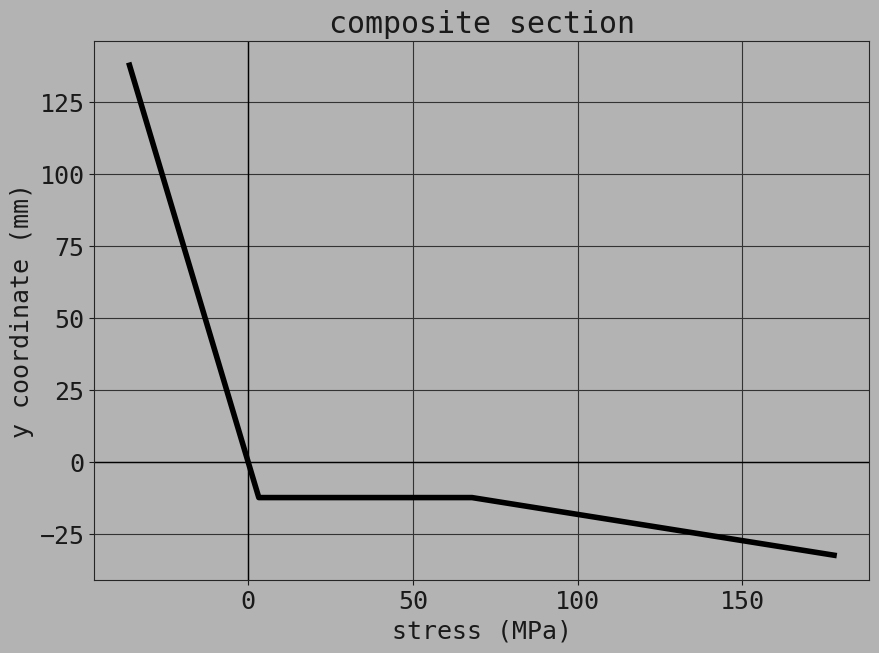

In [7]:
xplo = [yp1,yp2,yp3,yp4]
yplo = [sp1,sp2,sp3,sp4]

fz = 15
fig, ax = plt.subplots(figsize=(10,7))
plt.plot(yplo,xplo,'-k', linewidth=4)
plt.xlabel('stress (MPa)')
plt.ylabel('y coordinate (mm)')
plt.title('composite section')
ax.axhline(y=0, color='k', linewidth=1)
ax.axvline(x=0, color='k', linewidth=1)
ax.grid()
plt.show()

---

Copyright (c) DEMI - FCT NOVA

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>